In [1]:
!pip install -q torch torchvision matplotlib numpy tqdm

In [2]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
import numpy as np
from PIL import Image, ImageDraw
import matplotlib.pyplot as plt
from tqdm import tqdm
import os

os.makedirs("outputs/attn_gan", exist_ok=True)
device = "cuda" if torch.cuda.is_available() else "cpu"
print("Using device:", device)

SHAPE_LABELS = {0: "circle", 1: "square", 2: "triangle", 3: "star", 4: "hexagon"}

Using device: cuda


In [3]:
class SelfAttention(nn.Module):
    """Self-attention over spatial feature maps"""
    def __init__(self, in_channels):
        super().__init__()
        self.query = nn.Conv2d(in_channels, in_channels // 8, 1)
        self.key   = nn.Conv2d(in_channels, in_channels // 8, 1)
        self.value = nn.Conv2d(in_channels, in_channels, 1)
        self.gamma = nn.Parameter(torch.zeros(1))
        self.softmax = nn.Softmax(dim=-1)

    def forward(self, x):
        B, C, H, W = x.shape
        q = self.query(x).view(B, -1, H*W).permute(0, 2, 1)   # B, N, C'
        k = self.key(x).view(B, -1, H*W)                      # B, C', N
        attn = self.softmax(torch.bmm(q, k))                  # B, N, N
        v = self.value(x).view(B, -1, H*W)                    # B, C, N
        out = torch.bmm(v, attn.permute(0, 2, 1)).view(B, C, H, W)
        return self.gamma * out + x


class CrossAttention(nn.Module):
    """Cross-attention: spatial features attend to text embedding"""
    def __init__(self, feat_channels, text_dim, num_heads=4):
        super().__init__()
        self.num_heads = num_heads
        self.head_dim = feat_channels // num_heads
        self.q_proj = nn.Conv2d(feat_channels, feat_channels, 1)
        self.k_proj = nn.Linear(text_dim, feat_channels)
        self.v_proj = nn.Linear(text_dim, feat_channels)
        self.out_proj = nn.Conv2d(feat_channels, feat_channels, 1)
        self.scale = self.head_dim ** -0.5

    def forward(self, feat, text_emb):
        B, C, H, W = feat.shape
        N = H * W
        q = self.q_proj(feat).view(B, self.num_heads, self.head_dim, N).permute(0, 1, 3, 2)
        k = self.k_proj(text_emb).view(B, self.num_heads, self.head_dim, 1).permute(0, 1, 3, 2)
        v = self.v_proj(text_emb).view(B, self.num_heads, self.head_dim, 1).permute(0, 1, 3, 2)
        attn = torch.matmul(q, k.transpose(-2, -1)) * self.scale
        attn = F.softmax(attn, dim=-1)
        out = torch.matmul(attn, v).permute(0, 1, 3, 2).contiguous().view(B, C, H, W)
        return self.out_proj(out) + feat

In [4]:
class AttnGenerator(nn.Module):
    def __init__(self, z_dim=100, text_dim=50, n_classes=5):
        super().__init__()
        self.label_emb = nn.Embedding(n_classes, text_dim)

        self.fc = nn.Sequential(
            nn.Linear(z_dim + text_dim, 512*4*4),
            nn.BatchNorm1d(512*4*4),
            nn.ReLU(True)
        )

        self.up1 = nn.Sequential(
            nn.ConvTranspose2d(512, 256, 4, 2, 1, bias=False),
            nn.BatchNorm2d(256), nn.ReLU(True)
        )
        self.cross1 = CrossAttention(256, text_dim)
        self.self1  = SelfAttention(256)

        self.up2 = nn.Sequential(
            nn.ConvTranspose2d(256, 128, 4, 2, 1, bias=False),
            nn.BatchNorm2d(128), nn.ReLU(True)
        )
        self.cross2 = CrossAttention(128, text_dim)
        self.self2  = SelfAttention(128)

        self.up3 = nn.Sequential(
            nn.ConvTranspose2d(128, 64, 4, 2, 1, bias=False),
            nn.BatchNorm2d(64), nn.ReLU(True)
        )
        self.cross3 = CrossAttention(64, text_dim)

        self.final = nn.Sequential(
            nn.ConvTranspose2d(64, 3, 4, 2, 1, bias=False),
            nn.Tanh()
        )

    def forward(self, z, labels):
        t = self.label_emb(labels)
        x = torch.cat([z, t], dim=1)
        x = self.fc(x).view(-1, 512, 4, 4)

        x = self.up1(x)
        x = self.cross1(x, t)
        x = self.self1(x)

        x = self.up2(x)
        x = self.cross2(x, t)
        x = self.self2(x)

        x = self.up3(x)
        x = self.cross3(x, t)

        return self.final(x)


class AttnDiscriminator(nn.Module):
    def __init__(self, text_dim=50, n_classes=5):
        super().__init__()
        self.label_emb = nn.Embedding(n_classes, text_dim)
        self.conv = nn.Sequential(
            nn.Conv2d(3, 64, 4, 2, 1, bias=False), nn.LeakyReLU(0.2, True),
            nn.Conv2d(64, 128, 4, 2, 1, bias=False), nn.BatchNorm2d(128), nn.LeakyReLU(0.2, True),
            SelfAttention(128),
            nn.Conv2d(128, 256, 4, 2, 1, bias=False), nn.BatchNorm2d(256), nn.LeakyReLU(0.2, True),
            nn.Conv2d(256, 512, 4, 2, 1, bias=False), nn.BatchNorm2d(512), nn.LeakyReLU(0.2, True),
            nn.Flatten()
        )
        self.fc = nn.Sequential(
            nn.Linear(512*4*4 + text_dim, 512),
            nn.LeakyReLU(0.2, True),
            nn.Linear(512, 1)
        )

    def forward(self, img, labels):
        t = self.label_emb(labels)
        feat = self.conv(img)
        return self.fc(torch.cat([feat, t], dim=1))

print("Attention Generator and Discriminator defined")

Attention Generator and Discriminator defined


In [5]:
def generate_shape_image(label_idx, size=64):
    img = Image.new("RGB", (size, size), (0, 0, 0))
    draw = ImageDraw.Draw(img)
    m = size // 8
    c = (255, 255, 255)
    if label_idx == 0:
        draw.ellipse([m, m, size-m, size-m], fill=c)
    elif label_idx == 1:
        draw.rectangle([m, m, size-m, size-m], fill=c)
    elif label_idx == 2:
        draw.polygon([(size//2, m), (size-m, size-m), (m, size-m)], fill=c)
    elif label_idx == 3:
        cx = cy = size//2
        pts = []
        for i in range(5):
            a = np.deg2rad(90 + i*72)
            pts.append((cx + (size//2-m)*np.cos(a), cy - (size//2-m)*np.sin(a)))
            a2 = np.deg2rad(90 + i*72 + 36)
            pts.append((cx + (size//5)*np.cos(a2), cy - (size//5)*np.sin(a2)))
        draw.polygon(pts, fill=c)
    else:
        cx = cy = size//2
        r = size//2 - m
        pts = [(cx + r*np.cos(np.deg2rad(60*i)), cy + r*np.sin(np.deg2rad(60*i))) for i in range(6)]
        draw.polygon(pts, fill=c)
    arr = np.array(img).astype(np.float32)/255.0
    arr = (arr - 0.5)/0.5
    return arr.transpose(2,0,1)

images, labels = [], []
for idx in range(5):
    for _ in range(350):
        img = generate_shape_image(idx)
        noise = np.random.normal(0, 0.03, img.shape).astype(np.float32)
        images.append(np.clip(img + noise, -1, 1))
        labels.append(idx)

images = torch.tensor(np.stack(images), dtype=torch.float32)
labels = torch.tensor(labels, dtype=torch.long)
dataset = TensorDataset(images, labels)
loader = DataLoader(dataset, batch_size=64, shuffle=True, drop_last=True)
print("Dataset size:", len(dataset))

Dataset size: 1750


In [6]:
G = AttnGenerator().to(device)
D = AttnDiscriminator().to(device)

opt_G = optim.Adam(G.parameters(), lr=0.0002, betas=(0.5, 0.999))
opt_D = optim.Adam(D.parameters(), lr=0.0002, betas=(0.5, 0.999))
criterion = nn.BCEWithLogitsLoss()

epochs = 100
for epoch in range(1, epochs+1):
    d_losses, g_losses = [], []
    pbar = tqdm(loader, desc=f"Epoch {epoch}/{epochs}", leave=False)
    for real_imgs, real_labels in pbar:
        real_imgs, real_labels = real_imgs.to(device), real_labels.to(device)
        B = real_imgs.size(0)

        # Discriminator
        opt_D.zero_grad()
        real_loss = criterion(D(real_imgs, real_labels), torch.ones(B, 1, device=device))
        z = torch.randn(B, 100, device=device)
        fake_labels = torch.randint(0, 5, (B,), device=device)
        fake_imgs = G(z, fake_labels).detach()
        fake_loss = criterion(D(fake_imgs, fake_labels), torch.zeros(B, 1, device=device))
        d_loss = (real_loss + fake_loss) / 2
        d_loss.backward()
        opt_D.step()

        # Generator
        opt_G.zero_grad()
        z = torch.randn(B, 100, device=device)
        gen_labels = torch.randint(0, 5, (B,), device=device)
        g_loss = criterion(D(G(z, gen_labels), gen_labels), torch.ones(B, 1, device=device))
        g_loss.backward()
        opt_G.step()

        d_losses.append(d_loss.item())
        g_losses.append(g_loss.item())
        pbar.set_postfix(D=f"{d_loss.item():.3f}", G=f"{g_loss.item():.3f}")

    if epoch % 5 == 0 or epoch == epochs:
        print(f"Epoch {epoch}: D={np.mean(d_losses):.3f}  G={np.mean(g_losses):.3f}")

torch.save(G.state_dict(), "outputs/attn_gan/generator.pt")
print("Attention GAN trained and saved.")

Epoch 5: D=0.004  G=6.102


Epoch 10: D=0.001  G=7.783


Epoch 15: D=0.420  G=2.275


Epoch 20: D=0.421  G=1.967


Epoch 25: D=0.480  G=1.742


...

Epoch 80: D=0.303  G=3.318


Epoch 85: D=0.305  G=3.107


Epoch 90: D=0.305  G=3.149


Epoch 95: D=0.722  G=0.745


Epoch 100: D=0.701  G=0.766
Attention GAN trained and saved.


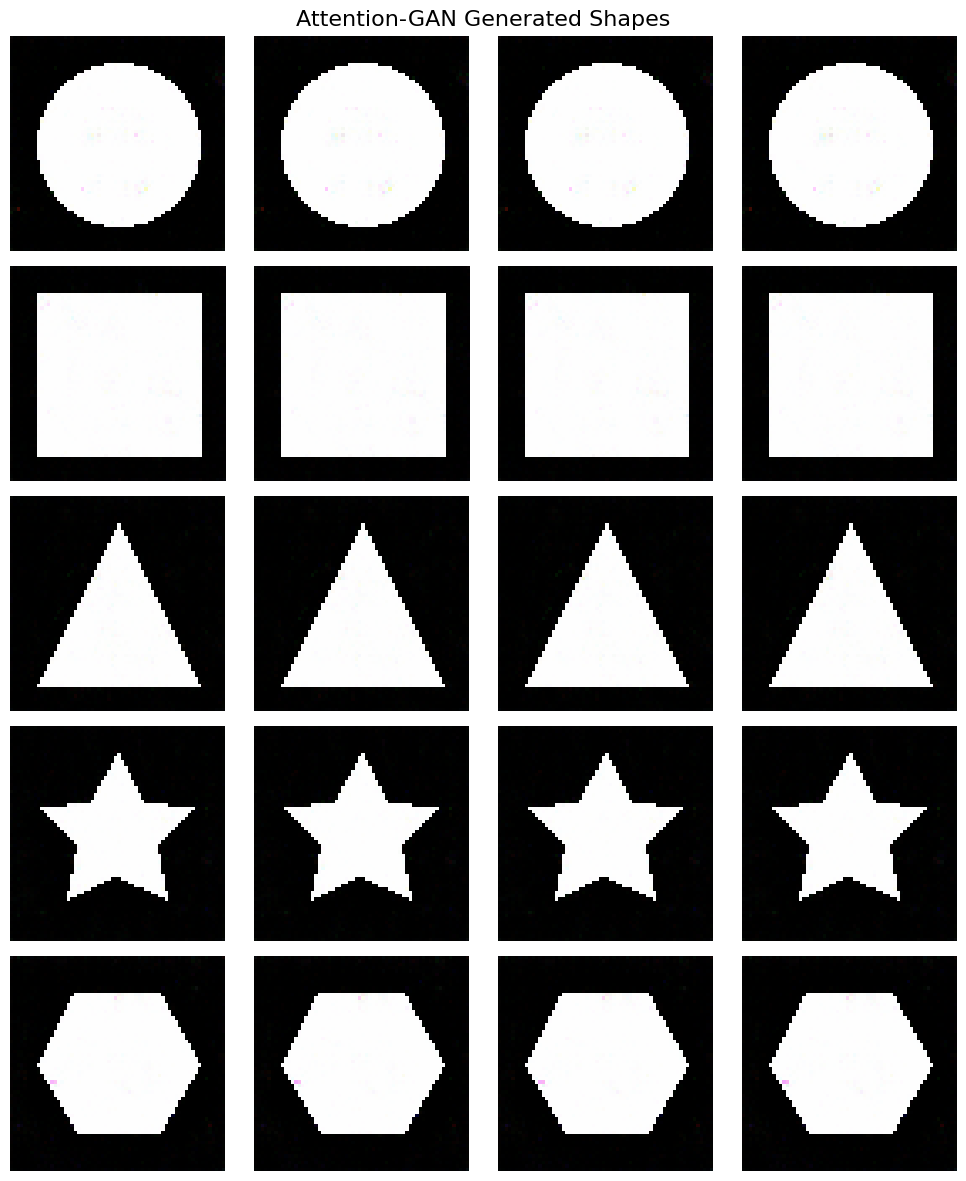

Saved → outputs/attn_gan/attn_shapes.png


In [7]:
G.eval()
fixed_z = torch.randn(20, 100, device=device)
fixed_labels = torch.arange(5, device=device).repeat_interleave(4)

with torch.no_grad():
    samples = G(fixed_z, fixed_labels)
    samples = (samples.clamp(-1, 1) + 1) / 2

fig, axes = plt.subplots(5, 4, figsize=(10, 12))
for i in range(5):
    for j in range(4):
        idx = i * 4 + j
        axes[i, j].imshow(samples[idx].cpu().permute(1, 2, 0).numpy())
        axes[i, j].axis("off")
        if j == 0:
            axes[i, j].set_ylabel(SHAPE_LABELS[i], rotation=0, labelpad=45, fontsize=13)

plt.suptitle("Attention-GAN Generated Shapes", fontsize=16)
plt.tight_layout()
plt.savefig("outputs/attn_gan/attn_shapes.png", dpi=130, bbox_inches="tight")
plt.show()
print("Saved → outputs/attn_gan/attn_shapes.png")

MY OBSERVATIONS (Day 4):

1. Self-Attention makes the model focus on connections between various components of the image.

2. Cross-Attention is an interaction where features in the image attend to the text/label embedding.

3. Attentions will generally result in cleaner and more consistent shapes when added.

4. This is a significant improvement on the basic CGAN from Day 3.

In today's text-to-image models (Stable Diffusion), attention is used widely.